# Running Light Curves

In [276]:
# --- In your notebook ---
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import sys
import pandas as pd
from itertools import islice
from IPython.display import display
import re
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast
import george
from collections import Counter
import pickle




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [277]:
%reload_ext autoreload

In [278]:


# If slsn_gp_lc.py lives in SLSNe_Metric/py_files/, add that parent to PYTHONPATH
repo_root = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric")
sys.path.insert(0, str(repo_root / "py_files"))  # contains slsn_gp_lc.py

# Import the module by name (matches filename without .py)
slsn_metric = importlib.import_module("local_SLSNe_metric")
importlib.reload(slsn_metric)
print("[CONFIG] Using Cristina's local MacBook setup")

# Import the module by name (matches filename without .py)
shared_utils = importlib.import_module("shared_utils")
importlib.reload(shared_utils)
print("[CONFIG] Using Cristina's local MacBook setup")

# Handy aliases
CatalogInputs = slsn_metric.CatalogInputs
SLSN_LC       = slsn_metric.LC



[CONFIG] Using Cristina's local MacBook setup
[CONFIG] Using Cristina's local MacBook setup


/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric local_SLSNe_metric.SLSN_Base_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric local_SLSNe_metric.SLSN_Detect_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric local_SLSNe_metric.SLSN_CharacterizeMetric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-p

In [247]:


repo_root = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric")
supernovae_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/SLSNe/slsne/ref_data/supernovae")
out_perevent   = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/per_event_files")

for csv in sorted(out_perevent.glob("*.csv")):
    # skip summary/derived files
    if csv.name.startswith("_") or csv.name.endswith("_cenwave.csv"):
        continue

    name = csv.stem  # no need to strip suffix now
    cen_map = slsn_metric.per_filter_cenwave(supernovae_dir, name, rel_bin=0.02, verbose=True)

    # Optional: audit variability (one-liner)
    diag_mode = slsn_metric.audit_cenwave_mode(supernovae_dir, name, rel_bin=0.02,
                                               outlier_frac_thresh=0.25)
    
    summary,var_df = slsn_metric.audit_cenwave_variability(supernovae_dir, name)
    
    if not var_df.empty and (var_df["flag_scatter"].any() or var_df["flag_trend"].any()):
        print(f"[audit] {name}: potential Cenwave variability flagged:")
        print(var_df.loc[var_df["flag_scatter"] | var_df["flag_trend"],
                         ["filter","rel_scatter","slope_A_per_day","r2"]])
    
    if not diag_mode.empty and diag_mode["flag_outliers"].any():
        print(f"[audit] {name}: filters with many outliers:")
        print(diag_mode.loc[diag_mode["flag_outliers"],
                            ["source","filter","n_rows","mode_center_A","frac_outside"]])


    slsn_metric.attach_cenwave_to_perevent_csv(csv, cen_map)



[cenwave] 1991D: entries kept -> model=3, rest=16, total=19 | rows seen -> model=1314, rest=12144 | groups seen -> model=3, rest=19 | rest skipped due to precedence=3
[cenwave] 1991D: model/rest overlap filters (model wins): B, R, V
[attach] wrote 1991D_cenwave.csv with Cenwave for 19/19 rows
[cenwave] 1999as: entries kept -> model=4, rest=15, total=19 | rows seen -> model=1768, rest=12144 | groups seen -> model=4, rest=19 | rest skipped due to precedence=4
[cenwave] 1999as: model/rest overlap filters (model wins): B, I, R, V
[attach] wrote 1999as_cenwave.csv with Cenwave for 43/43 rows
[cenwave] 1999bz: entries kept -> model=1, rest=19, total=20 | rows seen -> model=461, rest=12144 | groups seen -> model=1, rest=19 | rest skipped due to precedence=0
[attach] wrote 1999bz_cenwave.csv with Cenwave for 1/1 rows
[cenwave] 2002gh: entries kept -> model=3, rest=16, total=19 | rows seen -> model=1407, rest=12144 | groups seen -> model=3, rest=19 | rest skipped due to precedence=3
[cenwave] 2

In [282]:
# ========================================
# CONFIGURATION: Paths and Parameters
# ========================================

base_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests")
per_event_csv_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/per_event_files")
allparams_csv = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/all_events/allparameter.csv")

# ========================================
# SLSN-SPECIFIC SIMULATION PARAMETERS
# ========================================

# Rate: SLSNe are rare - ~1-10% of core-collapse SNe
# Core-collapse rate ~1e-4 Mpc^-3 yr^-1, so SLSN ~1e-6 to 1e-5
rate_density = 3e-8 # Mpc^-3 yr^-1 (conservative mid-range)

# Redshift: SLSNe discovered out to z~4, but most < z~2
# Your catalog spans z~0.02-1.6, so match that range
z_min, z_max = 0.02, 2.0

# Survey duration
t_start, t_end = 1, 3652  # 10 years

# Extinction: Yes, SLSNe are extragalactic
use_extinction = True

# K-correction: For SLSNe, spectral index approach is less valid
# They have blue UV continuum but also complex line features
# Better to use your GP-fitted SEDs if possible, but for now:
use_kcorrect = False  # Will use your sed_grid when you implement it
k_correct_type = None  # Not applicable if use_kcorrect=False
k_correct_arg = None

# Distance constraints: None needed - z determines distance
d_min, d_max = None, None
gal_lat_cut = None  # SLSNe are extragalactic, no Galactic plane cut

# Cadences to test
cadences = ['four_roll_v4.3.1_10yrs']
ignore_triples = True  # Standard for metrics

# Control flags
generate_new_templates = False  # Set True only if templates don't exist
generate_new_pop = True
make_debug_plots = True

# ========================================
# SLSN TEMPLATE PARAMETERS
# ========================================

# These match SLSN timescales:
# - Rise: ~20-40 days (faster than SNe Ia)
# - Peak duration: ~10-20 days
# - Decline: t_50(r) ~ 30-60 days
n_time_steps = 220
tpad_pre_peak = 5.0   # days before peak (SLSNe rise quickly)
tpad_post_peak = 160.0  # days after peak (need ~100d for decline rate)

print("SLSN Simulation Configuration:")
print(f"  Rate: {rate_density:.1e} Mpc^-3 yr^-1")
print(f"  Redshift: {z_min} - {z_max}")
print(f"  Survey: {t_end-t_start} days")
print(f"  Expected events (rough): ~{int(rate_density * 1e10 * (t_end-t_start)/365)}")

SLSN Simulation Configuration:
  Rate: 3.0e-08 Mpc^-3 yr^-1
  Redshift: 0.02 - 2.0
  Survey: 3651 days
  Expected events (rough): ~3000


In [284]:
# ========================================
# BUILD OUTPUT PATHS (includes templates_file)
# ========================================

templates_file_str, pop_file_str, df_file_str, storage_dir_str, summary_filename_str = shared_utils.build_filenames(
    rate_density=rate_density, 
    z_min=z_min, 
    z_max=z_max, 
    d_min=d_min, 
    d_max=d_max,
    science_case="SLSNe", 
    testname=None, 
    testname_metric_only=None,
    ignore_triples=ignore_triples, 
    use_extinction=use_extinction, 
    use_kcorrect=use_kcorrect,
    base_dir=base_dir
)

# Convert to Path objects
templates_file = Path(templates_file_str)
pop_file = Path(pop_file_str)
df_file = Path(df_file_str)
storage_dir = Path(storage_dir_str)
summary_filename = Path(summary_filename_str)

print(f"Output paths:")
print(f"  Templates: {templates_file}")
print(f"  Population: {pop_file}")
print(f"  Results: {df_file}")

# ========================================
# BUILD TEMPLATES
# ========================================

if not templates_file.exists():
    print(f"\n[BUILD] Creating templates...")
    
    # Ensure parent directory exists
    templates_file.parent.mkdir(parents=True, exist_ok=True)
    
    # Build from cenwave-enriched CSVs
    inputs = CatalogInputs(
        photometry_dir=per_event_csv_dir,
        params_table=pd.read_csv(allparams_csv),
        name_col="name",
        z_col="redshift_med",
        peak_mjd_col="Peak_MJD_med"
    )
    
    print(f"Processing {len(inputs.params_table)} events...")
    
    # This fits 2D GPs - will take several minutes
    shared_lc_model = SLSN_LC.from_catalog(
        inputs,
        filename_pattern="{name}_cenwave.csv",
        save_to=templates_file,
        n_time=220,
        tpad_pre_days=5.0,
        tpad_post_days=160.0,
        min_points_for_fit=6,
    )
    
    print(f"✓ Built {len(shared_lc_model.data)} templates")
    
else:
    print(f"\n[LOAD] Templates already exist at {templates_file}")
    shared_lc_model = SLSN_LC(load_from=templates_file)
    print(f"✓ Loaded {len(shared_lc_model.data)} templates")

grid_file = templates_file.parent / f"{templates_file.stem}_mag_grid.pkl"


print(f"✓ Bands: {shared_lc_model.filts}")
print(f"✓ First 5 events: {shared_lc_model.names[:5]}")



SLSNe_den_3e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None
Output paths:
  Templates: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None_templates.pkl
  Population: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None_population.pkl
  Results: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None_None_it_True_obs_record

[LOAD] Templates already exist at /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None_templates.pkl
✓ Loaded 261 templates


AttributeError: 'LC' object has no attribute 'filts'

In [190]:


event = "2011kf"

# find the template index for this event
# find the correct (z, t0)
idx = slsn_metric.template_index_for_event(templates_file, "2011kf")
z, t0 = slsn_metric.get_event_z_t0("2011kf", inputs.params_table, per_event_csv_dir)

# 1) observations (name, not index)
slsn_metric.plot_event_obs("2011kf",
    per_event_dir=per_event_csv_dir, use_phase=True, z=z, t0=t0, scale_to_peak=False)


# 2) model curves (index)
slsn_metric.plot_event_model(
    templates_file,
    template_idx=idx
)

# 3) overlay obs + model (name + index)
slsn_metric.plot_event_obs_vs_model(
    "2011kf",
    per_event_dir=per_event_csv_dir,
    templates_file=templates_file,
    template_idx=idx,
    use_phase=True, z=z, t0=t0,
    bands=["g","r","i","z"],
    scale_to_peak=False,
)






NameError: name 'inputs' is not defined

# Diagnostics

In [194]:


# 1) What filters exist in 2011kf_cenwave.csv?
p = per_event_csv_dir / "2011kf_cenwave.csv"
df = pd.read_csv(p)
cols = {c.lower(): c for c in df.columns}
print(sorted(df[cols["filter"]].astype(str).unique()))

# 2) For a given template index, list the model bands it actually has:
obj = pickle.load(open(templates_file, "rb"))
tpl = obj["lightcurves"][idx]   # use the idx you computed for 2011kf
print(sorted([k for k,v in tpl.items() if isinstance(v, dict) and {"ph","mag"}<=set(v)]))

# 3) Which events have a 'C' band? 
names = obj.get("names", [f"tpl_{i}" for i in range(len(obj["lightcurves"]))])
has_C = [n for n, tpl in zip(names, obj["lightcurves"])
         if any(k == "C" and isinstance(v, dict) and {"ph","mag"} <= set(v)
                for k, v in tpl.items())]
print("Events with C:", has_C)



['g', 'i', 'r', 'z']
['g', 'i', 'r', 'z']
Events with C: ['2011ep', '2014bl', '2016ard', '2017dwh', '2018fd', '2018jfo', 'CSS140925', 'CSS160710']


In [195]:


# 1) Apparent vs (Abs + DM)
df_res = slsn_metric.diagnose_abs_from_templates(
    event, per_event_csv_dir, templates_file, idx,
    z=z, t0=t0, bands=["g","r","i","z"], return_with_phase=True, verbose=True
)
slsn_metric.plot_residuals(df_res, by_band=True, title=f"{event}: m_obs − (M+DM)")
slsn_metric.plot_residuals(df_res, vs_phase=True, title=f"{event}: Residual vs Phase")

# 2) Internal GP consistency
df_int = slsn_metric.diagnose_internal_consistency(
    event, per_event_csv_dir, templates_file, idx,
    z=z, t0=t0, n_time=220, verbose=True
)
slsn_metric.plot_residuals(df_int, by_band=True, title=f"{event}: GP − (M+DM)")
slsn_metric.plot_residuals(df_int, vs_phase=True, title=f"{event}: GP Residual vs Phase")

# Quick audits
print("CSV bands:", slsn_metric.list_event_bands(per_event_csv_dir, event))
print("Template bands:", slsn_metric.list_template_bands(templates_file, idx))

NameError: name 'z' is not defined

In [286]:
def characterize_template_coverage(templates_file, save_summary=True):
    """Fast summary of template characteristics."""
    import pickle
    import pandas as pd
    import numpy as np
    
    with open(templates_file, 'rb') as f:
        obj = pickle.load(f)
    
    lcs = obj['lightcurves']
    names = obj.get('names', [f'tpl_{i}' for i in range(len(lcs))])
    meta = obj.get('meta', {})  # Dict with keys: z, dm, t0_cat, t0_data
    
    # Extract meta arrays (NOT indexing meta directly)
    z_arr = meta.get('z', [])
    dm_arr = meta.get('dm', [])
    t0_cat_arr = meta.get('t0_cat', [])
    t0_data_arr = meta.get('t0_data', [])
    
    rows = []
    for i, (name, tpl) in enumerate(zip(names, lcs)):
        row = {
            'tpl_idx': i, 
            'name': name,
            'z': z_arr[i] if i < len(z_arr) else np.nan,
            'dm': dm_arr[i] if i < len(dm_arr) else np.nan,
            't0_cat': t0_cat_arr[i] if i < len(t0_cat_arr) else np.nan,
            't0_data': t0_data_arr[i] if i < len(t0_data_arr) else np.nan,
        }
        
        # Count bands
        bands = [b for b, d in tpl.items() 
                 if isinstance(d, dict) and 'ph' in d and 'mag' in d and len(d['ph']) > 0]
        row['n_bands'] = len(bands)
        row['bands'] = ','.join(sorted(bands))
        
        # Get reference band characteristics
        for check_band in ['r', 'g', 'i']:
            if check_band in tpl and isinstance(tpl[check_band], dict):
                ph = np.asarray(tpl[check_band].get('ph', []), float)
                mag = np.asarray(tpl[check_band].get('mag', []), float)
                if len(ph) > 0:
                    row['ref_band'] = check_band
                    row['phase_min'] = float(ph.min())
                    row['phase_max'] = float(ph.max())
                    row['phase_span'] = float(ph.max() - ph.min())
                    row['n_phases'] = len(ph)
                    row['mag_peak'] = float(mag[np.argmin(np.abs(ph))])
                    break
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    if save_summary:
        summary_path = templates_file.parent / f"{templates_file.stem}_coverage_summary.csv"
        df.to_csv(summary_path, index=False)
        print(f"Saved to {summary_path}")
    
    return df
# Now this will work:
df_cov = characterize_template_coverage(templates_file)
print(f"\n{len(df_cov)} templates loaded")
print(f"Bands per template: {df_cov['n_bands'].describe()}")
print(f"Phase coverage: {df_cov['phase_span'].describe()}")
print(f"Most common bands: {df_cov['bands'].value_counts().head()}")

Saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None_templates_coverage_summary.csv

261 templates loaded
Bands per template: count    261.000000
mean       5.919540
std        3.319702
min        1.000000
25%        4.000000
50%        5.000000
75%        7.000000
max       21.000000
Name: n_bands, dtype: float64
Phase coverage: count    240.000000
mean     116.023164
std       26.441545
min       32.601806
25%      104.534878
50%      121.475584
75%      135.807058
max      155.572248
Name: phase_span, dtype: float64
Most common bands: bands
g,i,r,z                34
cyan,g,i,orange,r      31
cyan,g,orange,r        16
g,i,r                  12
G,cyan,g,i,orange,r    11
Name: count, dtype: int64


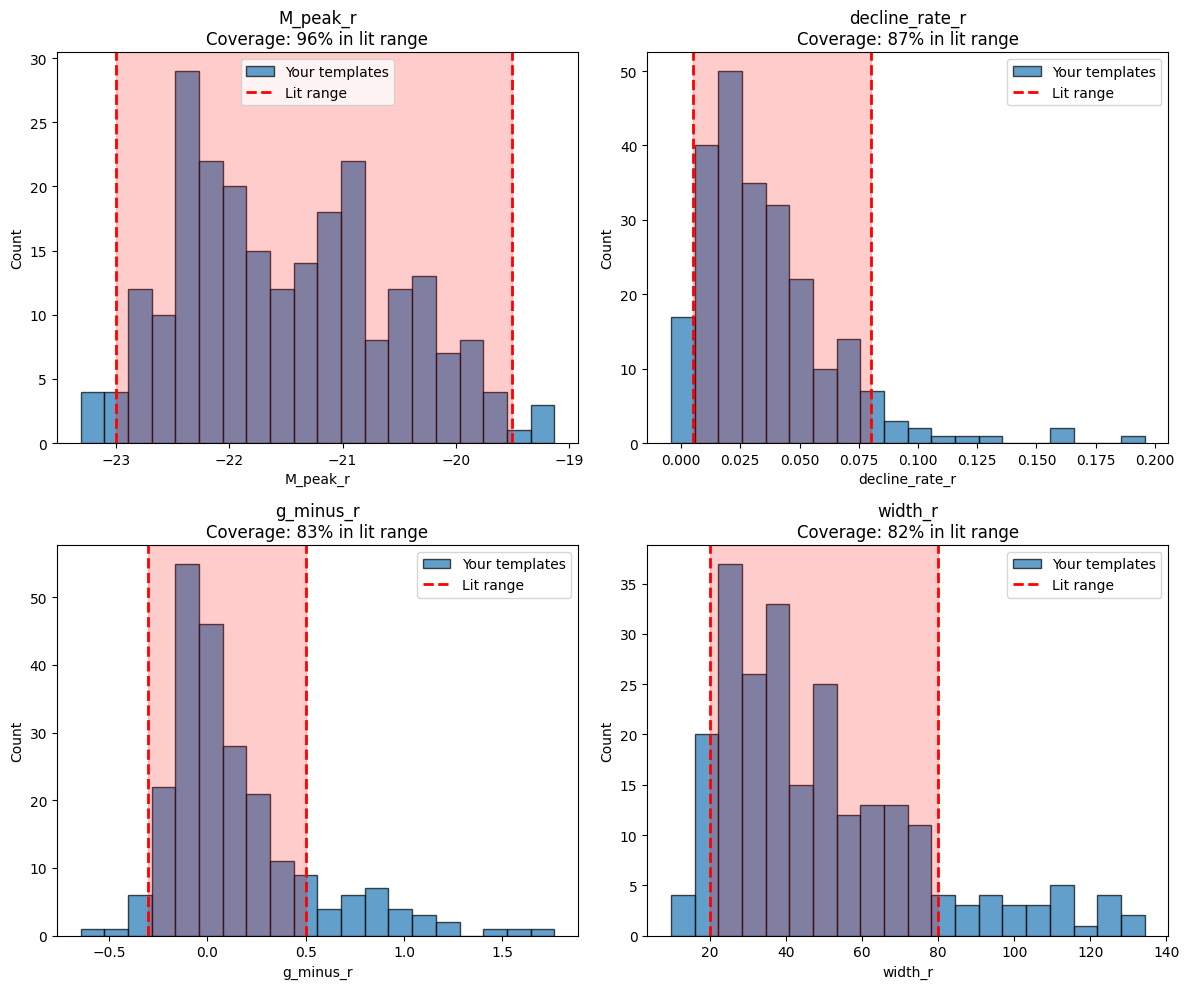


=== Coverage Assessment ===
M_peak_r            : good
decline_rate_r      : missing_bright_end
g_minus_r           : missing_faint_end
width_r             : missing_bright_end


In [288]:
def compute_slsn_properties(df_cov, templates_file):
    """
    Compute SLSN-specific observable properties from templates.
    """
    import pickle
    import numpy as np
    
    with open(templates_file, 'rb') as f:
        obj = pickle.load(f)
    
    lcs = obj['lightcurves']
    
    rows = []
    for i, tpl in enumerate(lcs):
        row = {'tpl_idx': i}
        
        # Get r-band curve
        if 'r' in tpl and isinstance(tpl['r'], dict):
            ph = np.asarray(tpl['r']['ph'], float)
            mag = np.asarray(tpl['r']['mag'], float)
            
            if len(ph) > 5:
                # Peak absolute magnitude
                peak_idx = np.argmin(mag)
                row['M_peak_r'] = float(mag[peak_idx])
                
                # Decline rate: 15-50 days post-peak
                post = (ph > 0) & (ph >= 15) & (ph <= 50)
                if post.sum() >= 3:
                    from scipy.stats import linregress
                    slope, _, _, _, _ = linregress(ph[post], mag[post])
                    row['decline_rate_r'] = float(slope)
                
                # Width at M_peak + 1 mag
                thresh = row['M_peak_r'] + 1.0
                above = mag < thresh
                if above.sum() >= 2:
                    row['width_r'] = float(ph[above].max() - ph[above].min())
        
        # g-r color at peak
        if 'g' in tpl and 'r' in tpl:
            g_mag = np.asarray(tpl['g']['mag'], float)
            g_ph = np.asarray(tpl['g']['ph'], float)
            r_mag = np.asarray(tpl['r']['mag'], float)
            r_ph = np.asarray(tpl['r']['ph'], float)
            
            # Find mags closest to phase=0
            if len(g_ph) > 0 and len(r_ph) > 0:
                g_near_peak = g_mag[np.argmin(np.abs(g_ph))]
                r_near_peak = r_mag[np.argmin(np.abs(r_ph))]
                row['g_minus_r'] = float(g_near_peak - r_near_peak)
        
        rows.append(row)
    
    df_props = pd.DataFrame(rows)
    
    # Merge with coverage info
    return df_cov.merge(df_props, on='tpl_idx', how='left')

# Compute properties FIRST
df_cov_full = compute_slsn_properties(df_cov, templates_file)

# NOW assess coverage
gaps = slsn_metric.assess_literature_coverage(df_cov_full)

In [290]:

missing = slsn_metric.find_missing_archetypes(df_cov)


✓ Good coverage across major SLSN types


# Generating Population, Measuring Detection Efficiency 

[INFO] z_min = 0.02000 -> d_min = 88.202088314593198 Mpc
[INFO] z_max = 2.00000 -> d_max = 5308.188883886385156 Mpc
Simulating 188142 SLSNe (rate=3.0e-08 Mpc^-3 yr^-1)
[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None_population.pkl
Saved SLSN population to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None_population.pkl
✓ Generated/loaded 188142 SLSN events
  z range: 0.020 - 2.000
  peak times: 1.0 - 3652.0 days


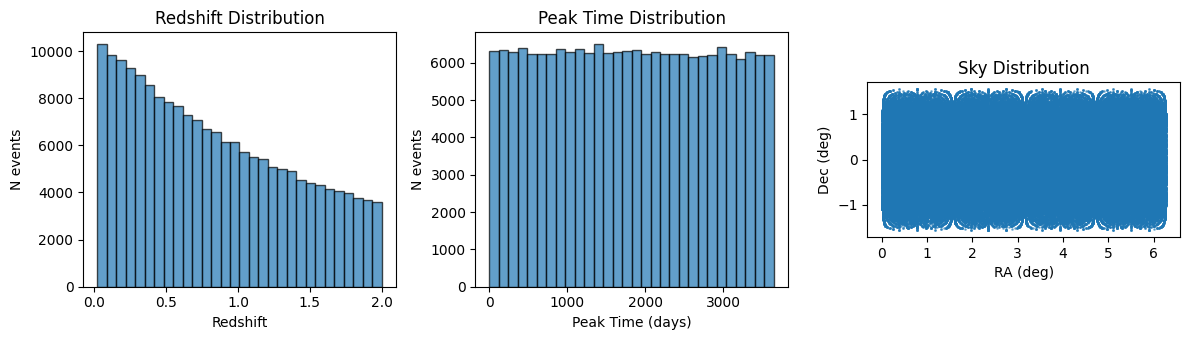

In [292]:
#Generate population using SLSN-specific function
slicer = slsn_metric.generate_SLSN_PopSlicer(
    lc_model=shared_lc_model,
    t_start=t_start,
    t_end=t_end,
    z_min=z_min,
    z_max=z_max,
    rate_density=rate_density,
    gal_lat_cut=gal_lat_cut,
    seed=42,
    save_to=pop_file if generate_new_pop else None,
    load_from=pop_file if not generate_new_pop else None
)

print(f"✓ Generated/loaded {len(slicer.slice_points['z'])} SLSN events")
print(f"  z range: {slicer.slice_points['z'].min():.3f} - {slicer.slice_points['z'].max():.3f}")
print(f"  peak times: {slicer.slice_points['peak_time'].min():.1f} - {slicer.slice_points['peak_time'].max():.1f} days")

# Optional: Quick diagnostics
if make_debug_plots:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    
    # Redshift distribution
    axes[0].hist(slicer.slice_points['z'], bins=30, edgecolor='k', alpha=0.7)
    axes[0].set_xlabel('Redshift')
    axes[0].set_ylabel('N events')
    axes[0].set_title('Redshift Distribution')
    
    # Peak time distribution
    axes[1].hist(slicer.slice_points['peak_time'], bins=30, edgecolor='k', alpha=0.7)
    axes[1].set_xlabel('Peak Time (days)')
    axes[1].set_ylabel('N events')
    axes[1].set_title('Peak Time Distribution')
    
    # Sky distribution
    axes[2].scatter(slicer.slice_points['ra'], slicer.slice_points['dec'], 
                   s=1, alpha=0.5)
    axes[2].set_xlabel('RA (deg)')
    axes[2].set_ylabel('Dec (deg)')
    axes[2].set_title('Sky Distribution')
    axes[2].set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

Loaded SLSN population from /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None_population.pkl
✓ Generated/loaded 188142 SLSN events

--- Running four_roll_v4.3.1_10yrs ---

Inspecting one obs_record before saving to CSV:
filter          | type: <class 'list'> | length: 754
mjd_obs         | type: <class 'list'> | length: 754
mag_obs         | type: <class 'list'> | length: 754
snr_obs         | type: <class 'list'> | length: 754
phase_rest      | type: <class 'list'> | length: 754
detected        | type: <class 'bool'> | value: False
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 179
z               | type: <class 'numpy.float64'> | value: 0.6341002834557147
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
di

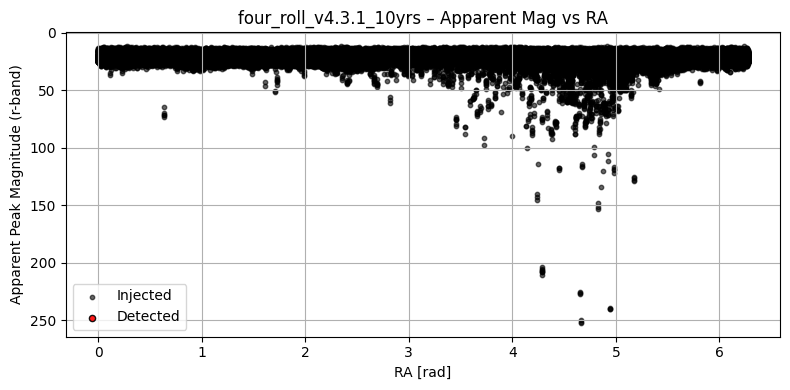

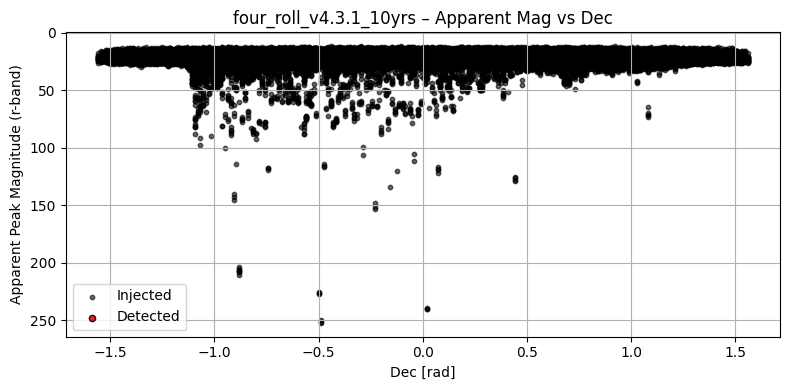

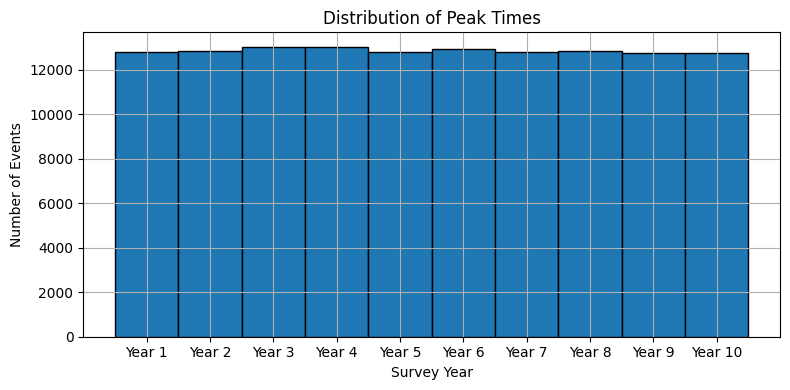

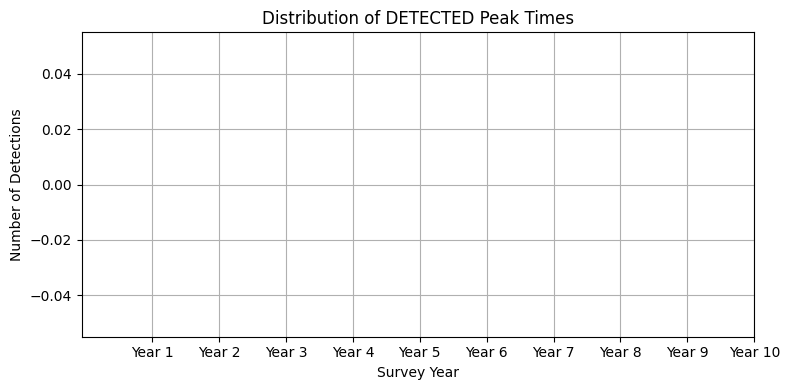

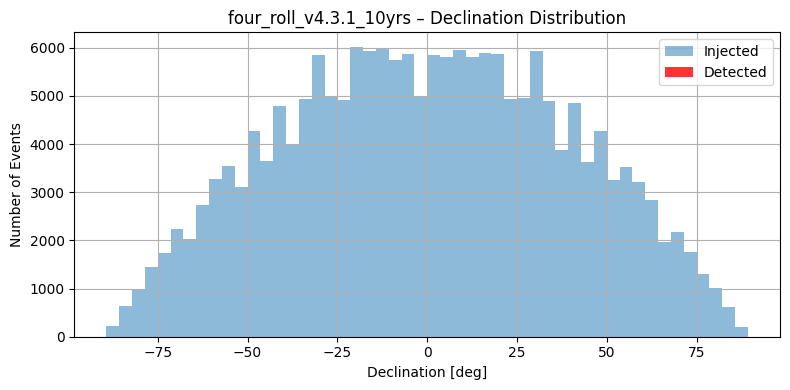

In [308]:
seed = 42
# First, CREATE the slicer object (don't pass the function)
slicer = generate_SLSN_PopSlicer(
    lc_model=shared_lc_model,
    t_start=t_start,
    t_end=t_end,
    z_min=z_min,
    z_max=z_max,
    rate_density=rate_density,
    seed=seed,
    save_to=pop_file,
    load_from=pop_file if pop_file.exists() else None
)

print(f"✓ Generated/loaded {len(slicer.slice_points['z'])} SLSN events")

# Then pass the SLICER OBJECT (not the function) to run_detect
from shared_utils import run_detect

df_obs = run_detect(
    metric=slsn_metric,           # your metric MODULE
    slicer=slicer,                # ← PASS THE SLICER OBJECT, NOT THE FUNCTION
    cadences=['four_roll_v4.3.1_10yrs'],
    shared_lc_model=shared_lc_model,  # ← PASS THE LC MODEL OBJECT, NOT LC.from_catalog
    db_dir=str(db_dir),           # path to your opsim databases
    storage_dir=str(storage_dir),
    df_file=str(df_file),
    use_extinction=True,
    use_kcorrect=False,
    is_grb=False,
    debug=True,
    plot=True
)

In [302]:
# ========================================
# DETECTION SIMULATION
# ========================================

from local_SLSNe_metric import SLSN_Detect_Metric
import local_SLSNe_metric as slsn_module

import pickle, pathlib
templates_file = pathlib.Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_1e-07_d_None-None_Mpc_z_0.02-2.0_ext_True_kcor_False_None_templates.pkl")  # <-- set correctly

with open(templates_file, "rb") as f:
    obj = pickle.load(f)

shared_lc_model.template_file = str(templates_file)
shared_lc_model.sed_grid = obj["sed_grid"]          # keep in memory (faster)
# optional: names too, if you want them
shared_lc_model.names = obj.get("names", getattr(shared_lc_model, "names", []))



# Create detection metric
detect_metric = SLSN_Detect_Metric(
    lc_model=shared_lc_model,
    use_extinction=use_extinction,
    use_kcorrect=use_kcorrect,
    mjd0=60980.5  # Survey start (can adjust)
)

# You need cadence database paths - UPDATE THESE
db_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")

# Check database exists
baseline_db = db_dir / "four_roll_v4.3.1_10yrs.db"
if not baseline_db.exists():
    raise FileNotFoundError(f"Cadence database not found: {baseline_db}")

print(f"✓ Using cadence database: {baseline_db}")

# Run detection (this will take time - starts with 1 cadence)
from shared_utils import run_detect

df_obs = run_detect(
    metric=slsn_metric,  # your metric module
    slicer=generate_SLSN_PopSlicer,
    cadences=['baseline_v3.4_10yrs'],
    shared_lc_model=LC.from_catalog,
    db_dir="path/to/dbs",
    storage_dir="output/SLSN",
    df_file="output/SLSN/obs_records_",
    use_extinction=True,
    use_kcorrect=False,
    is_grb=False,  # ← IMPORTANT
    debug=True,
    plot=True
)

# Results summary
print(f"\n{'='*60}")
print(f"DETECTION RESULTS")
print(f"{'='*60}")
print(f"Total events simulated: {len(df_results)}")
print(f"Detected (bronze): {df_results['detected'].sum()}")
print(f"Detection rate: {df_results['detected'].mean():.1%}")
print(f"\nBy redshift:")
print(df_results.groupby(pd.cut(df_results['z'], bins=[0, 0.5, 1.0, 1.5, 2.0]))['detected'].agg(['count', 'sum', 'mean']))

✓ Using cadence database: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/four_roll_v4.3.1_10yrs.db


AttributeError: 'function' object has no attribute 'slice_points'

In [ ]:
from rubin_sim.phot_utils import Bandpass, Sed
from rubin_sim.data import get_data_dir
import numpy as np, os

bp = Bandpass()
bp.read_throughput(os.path.join(get_data_dir(), "throughputs", "baseline", "total_r.dat"))

lam = np.linspace(5000, 8000, 500)  # Å
flam = np.ones_like(lam) * 1e-16
sed = Sed(wavelen=lam, flambda=flam)
print("OK, AB mag:", sed.calc_mag(bp))
